## Travelling Salesman Problem

### Breaking the Deadlock — Simulated Annealing in Hopfield Networks

Hello again! By now, you’ve seen the beauty of the **Hopfield Network**: a system of differential equations that acts like a physical landscape where a ball rolls down to find the minimum energy.

But there’s a catch. If you’ve run your previous Python code for $N > 10$ cities, you probably noticed the "ball" often gets stuck in a shallow "pothole" on the side of the mountain. In mathematics, we call this a **local minimum**. It’s a solution that satisfies the rules (constraints), but it isn't the *shortest* path (the global minimum).

Today, we learn how to "shake" the mountain to get the ball out of the pothole. This is **Simulated Annealing (SA)**.

### 1. The Physics of the "Shake"

In thermodynamics, if you cool a liquid metal too quickly, the atoms freeze into a chaotic, weak structure. But if you cool it slowly (**annealing**), the atoms have enough thermal energy to "jiggle" out of unstable positions and settle into a perfect, low-energy crystal.

In our Hopfield network, "Temperature" ($T$) represents **stochastic noise**.

* **High $T$:** The network is "hot" and jumps around wildly. It can jump *up* an energy hill to escape a local minimum.
* **Low $T$:** The network is "cold" and becomes deterministic, rolling strictly downward to settle into a final state.

### 2. Deriving the Energy Difference ($\Delta E$)

To decide whether to accept a random "jiggle" (a change in our neuron states), we need to know how much that change affects the total energy.

Recall our 4-term Hopfield Energy Functional:


$$E = \frac{A}{2} \sum_{x} \sum_{i} \sum_{j \neq i} V_{xi}V_{xj} + \frac{B}{2} \sum_{i} \sum_{x} \sum_{y \neq x} V_{xi}V_{yi} + \frac{C}{2} \left( \sum_{x} \sum_{i} V_{xi} - n \right)^2 + \frac{D}{2} \sum_{x} \sum_{y \neq x} \sum_{i} d_{xy} V_{xi}(V_{y,i+1} + V_{y,i-1})$$

Suppose we propose a change to a single neuron $V_{xi}$ (flipping it from $0$ to $1$ or vice-versa). The change in energy, $\Delta E$, is:


$$\Delta E = E_{\text{new}} - E_{\text{old}}$$

Since $E$ is a quadratic form, the difference $\Delta E$ for changing neuron $V_{xi}$ is directly proportional to the "local field" (the gradient we derived in the last lecture). If we flip the state of $V_{xi}$ by an amount $\Delta V_{xi}$, the energy change is:


$$\Delta E \approx \frac{\partial E}{\partial V_{xi}} \Delta V_{xi}$$

In a discrete Simulated Annealing setup for TSP, we often swap the positions of two cities. This keeps the row/column constraints mostly intact while changing the $D$ (distance) term and testing if the new path is "cheaper."

### 3. The Metropolis Criterion: Why the Probability?

We use the **Metropolis-Hastings** statement to decide if we accept a move:

1. If $\Delta E < 0$ (the move is better), **always accept it**.
2. If $\Delta E > 0$ (the move is worse), **accept it with probability**:

$$P(\text{accept}) = e^{-\frac{\Delta E}{T}}$$



**Why this specific formula?**

* **The Role of $T$:** When $T$ is huge, $e^{- \Delta E / T}$ is close to $1$. We accept almost everything, allowing the network to explore the whole "map."
* **The Role of $\Delta E$:** A slightly worse move (small $\Delta E$) is much more likely to be accepted than a catastrophically worse move (large $\Delta E$).
* **Convergence:** As $T \to 0$, the probability of accepting a bad move vanishes. The system "freezes" into the best spot it found during its high-temperature exploration.

### 4. Python Implementation: SA with Hopfield Constraints

This code applies Simulated Annealing to the full Hopfield Energy Functional. We propose random "swaps" and use the Metropolis criterion to decide their fate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- Generate cities
def generate_cities(n):
    return np.random.rand(n, 2)

In [3]:
# --- Distancies
def get_dist_matrix(coords):
    return np.sqrt(np.sum((coords[:, None] - coords[None, :])**2, axis=2))

In [4]:
# --- The Energy Functional (The Hopfield Rules) ---
def hopfield_energy(V, dist_matrix, A, B, C, D):
    n = V.shape[0]
    # Row penalty: each city visited once
    e_a = (A/2) * np.sum((np.sum(V, axis=1) - 1)**2)
    # Column penalty: each stop has one city
    e_b = (B/2) * np.sum((np.sum(V, axis=0) - 1)**2)
    # Global penalty: exactly n neurons active
    e_c = (C/2) * (np.sum(V) - n)**2
    
    # Distance penalty: total path length
    e_d = 0
    for i in range(n):
        prev, nxt = (i - 1) % n, (i + 1) % n
        # Multiply distance matrix by adjacency in tour
        e_d += np.sum(dist_matrix * np.outer(V[:, i], V[:, prev] + V[:, nxt]))
    
    return e_a + e_b + e_c + (D/2) * e_d

In [5]:
# --- Simulated Annealing Engine ---
def solve_tsp_sa(cities, iterations=10000, T_start=100.0, alpha=0.999):
    n = len(cities)
    dist_matrix = get_dist_matrix(cities)
    
    # Hyperparameters
    A, B, C, D = 500, 500, 200, 500
    
    # Initial State: Start with a random valid tour
    current_tour = np.random.permutation(n)
    V = np.zeros((n, n))
    for i, city in enumerate(current_tour):
        V[city, i] = 1
    
    current_energy = hopfield_energy(V, dist_matrix, A, B, C, D)
    T = T_start
    
    history = []

    for i in range(iterations):
        # Propose a change: Swap two positions in the tour
        new_tour = current_tour.copy()
        idx1, idx2 = np.random.choice(n, 2, replace=False)
        new_tour[idx1], new_tour[idx2] = new_tour[idx2], new_tour[idx1]
        
        # Build new V matrix
        V_new = np.zeros((n, n))
        for j, city in enumerate(new_tour):
            V_new[city, j] = 1
        
        new_energy = hopfield_energy(V_new, dist_matrix, A, B, C, D)
        delta_e = new_energy - current_energy
        
        # Metropolis Criterion
        if delta_e < 0 or np.random.rand() < np.exp(-delta_e / T):
            current_tour = new_tour
            V = V_new
            current_energy = new_energy
        
        # Cooling
        T *= alpha
        if i % 100 == 0: history.append(current_energy)
            
    return current_tour, history

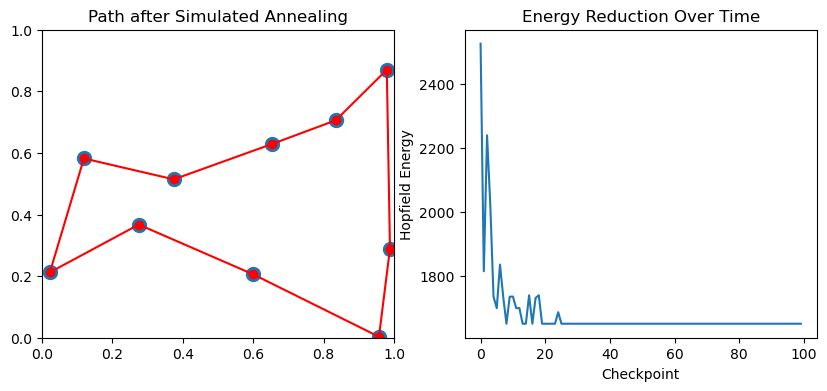

In [6]:
# --- Execution & Visualization ---
N = 10
coords = generate_cities(N)
tour, energy_hist = solve_tsp_sa(coords)

# Plotting the Resulting Path
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.xlim(0, 1) 
plt.ylim(0, 1) 
path = coords[np.append(tour, tour[0])]
plt.scatter(coords[:, 0], coords[:, 1], s=100);
plt.plot(path[:, 0], path[:, 1], 'ro-')
plt.title("Path after Simulated Annealing")

# Plotting the Energy Convergence
plt.subplot(1, 2, 2)
plt.plot(energy_hist)
plt.title("Energy Reduction Over Time")
plt.xlabel("Checkpoint")
plt.ylabel("Hopfield Energy")
plt.show()

### Final Mathematical Note

You'll notice that the energy doesn't just go down—it "jitters." Those spikes in the energy graph are the moments where the system accepted a *worse* path to escape a local minimum. Without those spikes, the network would likely have settled on a much longer, inferior tour.

Would you like me to show you how to visualize the **Cooling Schedule** alongside the energy to see exactly when the "freezing" point occurs?